# PixelCNN: A Generative Model
PixelCNN is a type of autoregressive generative model developed for modeling images. It captures the dependencies between pixels, allowing it to generate new images pixel by pixel. Unlike traditional generative models, PixelCNN models the conditional distribution of each pixel given the previous ones.


## Autoregressive Models
Autoregressive models aim to predict the next element in a sequence based on prior elements. In the context of images, PixelCNN models the probability distribution of each pixel given all previous pixels in raster order (top to bottom, left to right). This enables generating images from scratch.

The key idea of PixelCNN is to factor the image's joint distribution into a product of conditional distributions:
$$ P(x) = \prod_i P(x_i | x_{1:i-1}) $$

Where each pixel is conditioned on the previous pixels.


## PixelCNN Architecture
PixelCNN uses a stack of convolutional layers where each layer is masked to ensure that the pixel at position (i, j) only depends on previous pixels. The network models the conditional probability of a pixel given its neighbors.

The structure can be visualized as:

![PixelCNN Architecture](https://camo.githubusercontent.com/2f581257c289298057989d11aa1ad507c2af397b2471c592f7b17a5dbecd731e/687474703a2f2f736572676569747572756b696e2e636f6d2f6173736574732f323031372d30322d32322d3138333031305f343739783439345f7363726f742e706e67)  <!-- Add actual image reference here -->


## PixelCNN Architecture
PixelCNN uses a stack of convolutional layers where each layer is masked to ensure that the pixel at position (i, j) only depends on previous pixels. The network models the conditional probability of a pixel given its neighbors.

The structure can be visualized as:

![PixelCNN Architecture](https://camo.githubusercontent.com/2b432c6d87633c75685c3703167c0a6b5a6d6592a7ca95540bf02f6de890052c/68747470733a2f2f6c696c69616e77656e672e6769746875622e696f2f6c696c2d6c6f672f6173736574732f696d616765732f706978656c2d636e6e2e706e67)  <!-- Add actual image reference here -->


## Masked Convolutions
PixelCNN employs masked convolutions to ensure that future pixels are not used in the computation of the current pixel's distribution. There are two types of masks:

- **Mask A**
- **Mask B**

This technique helps preserve the autoregressive nature of the model.


## Implementation

PyTorch buffers are tensor attributes associated with a PyTorch module or model similar to parameters, but unlike parameters, buffers are not updated during training.



In [2]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import time
import matplotlib.pyplot as plt
from google.colab import drive
from torch.autograd import Variable
import os
import torch

In [3]:
class MaskedConv2d(nn.Conv2d):
    """
    Class extending nn.Conv2d to use masks.
    """
    def __init__(self, mask_type, in_channels, out_channels, kernel_size, padding=0, bias=True):
        super(MaskedConv2d, self).__init__(in_channels, out_channels, kernel_size, padding=padding, bias=bias)
        self.register_buffer('mask',  torch.ones_like(self.weight))


        _, _, height, width = self.weight.size()
        self.mask.fill_(1)

        self.mask[:, :, height // 2 + 1:, :] = 0
        self.mask[:, :, height // 2, width // 2 + (mask_type == 'B'):] = 0

    def forward(self, x):
        self.weight.data *= self.mask
        return super(MaskedConv2d, self).forward(x)



In [4]:
class PixelCNN(nn.Module):
    def __init__(self, in_channels=1, hidden_channels=64, kernel_size=7, num_layers=8, device=None):
        super(PixelCNN, self).__init__()
        self.layers = nn.ModuleList()
        self.device = device
        self.layers.append(
            nn.Sequential(
                MaskedConv2d('A', in_channels, hidden_channels, kernel_size, padding=kernel_size // 2),
                nn.BatchNorm2d(hidden_channels),
                nn.ReLU(True)
            )
        )
        for i in range(num_layers - 1):
            self.layers.append(
                nn.Sequential(
                    MaskedConv2d('B', hidden_channels, hidden_channels, kernel_size, padding=kernel_size // 2),
                    nn.BatchNorm2d(hidden_channels),
                    nn.ReLU(True)
                )
            )

        self.output_layer = nn.Conv2d(hidden_channels, 256, kernel_size=1)

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        x = self.output_layer(x)
        return x

In [5]:
class BinarizeTransform:
    def __call__(self, img):
        tensor_img = transforms.ToTensor()(img)
        binarized_img = (tensor_img > 0.5).float()
        return binarized_img

transform = transforms.Compose([
    BinarizeTransform()
    ])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, transform=transform, download=True)

batch_size = 64

train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True, num_workers=1, pin_memory=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False, num_workers=1, pin_memory=True)


Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 9.91M/9.91M [00:00<00:00, 16.0MB/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 28.9k/28.9k [00:00<00:00, 490kB/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 1.65M/1.65M [00:00<00:00, 4.40MB/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 4.54k/4.54k [00:00<00:00, 5.65MB/s]

Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



In [11]:
from google.colab import drive

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = PixelCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters())
loss_overall = []
epochs = 25

drive.mount('/content/drive')
checkpoint_path = '/content/drive/My Drive/checkpoint.pth'

start_epoch = 0

# Load checkpoint if it exists
if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    loss_overall = checkpoint['loss_overall']
    print(f"Loaded checkpoint from epoch {start_epoch - 1}")


for epoch in range(start_epoch, epochs):
    model.train(True)
    epoch_loss = 0
    step = 0

    for images, labels in train_loader:

        target = Variable(images[:,0,:,:]*1).long()

        images = images.to(device)
        target = target.to(device)

        optimizer.zero_grad()

        output = model(images)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        epoch_loss+=loss
        step+=1

        if(step%100 == 0):
          print('Epoch:'+str(epoch)+'\t'+ str(step) +'\t Iterations Complete \t'+'loss: ', loss.item())
          loss_overall.append(epoch_loss)
          epoch_loss=0

    print('Epoch: '+str(epoch)+' Over!')

    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss_overall': loss_overall
    }, checkpoint_path)
    print(f"Checkpoint saved for epoch {epoch}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Epoch:0	100	 Iterations Complete 	loss:  0.7401730418205261
Epoch:0	200	 Iterations Complete 	loss:  0.29450827836990356
Epoch:0	300	 Iterations Complete 	loss:  0.21753904223442078
Epoch:0	400	 Iterations Complete 	loss:  0.11322485655546188
Epoch:0	500	 Iterations Complete 	loss:  0.09546235203742981
Epoch:0	600	 Iterations Complete 	loss:  0.08878936618566513
Epoch:0	700	 Iterations Complete 	loss:  0.08804887533187866
Epoch:0	800	 Iterations Complete 	loss:  0.0890493392944336
Epoch:0	900	 Iterations Complete 	loss:  0.0907740369439125
Epoch: 0 Over!
Checkpoint saved for epoch 0
Epoch:1	100	 Iterations Complete 	loss:  0.0804055780172348
Epoch:1	200	 Iterations Complete 	loss:  0.07965309917926788
Epoch:1	300	 Iterations Complete 	loss:  0.08676507323980331
Epoch:1	400	 Iterations Complete 	loss:  0.0822172686457634
Epoch:1	500	 Iterations Complete 	loss:

In [17]:
model.eval()
test_loss = 0
with torch.no_grad():
  for images, labels in test_loader:
    target = Variable(images[:, 0, :, :] * 1).long()
    images = images.to(device)
    target = target.to(device)
    output = model(images)
    loss = criterion(output, target)
    test_loss += loss.item()

    avg_test_loss = test_loss / len(test_loader)
    print(f"Average Test Loss: {avg_test_loss}")


Average Test Loss: 0.00045609630786689226
Average Test Loss: 0.000929658959625633
Average Test Loss: 0.0013725737192828184
Average Test Loss: 0.0018260799300898413
Average Test Loss: 0.0022929974232509635
Average Test Loss: 0.002744648012386006
Average Test Loss: 0.003220696690355896
Average Test Loss: 0.0037086961945151068
Average Test Loss: 0.004191754255325171
Average Test Loss: 0.004676020306766413
Average Test Loss: 0.005131830692670907
Average Test Loss: 0.0055835435914385854
Average Test Loss: 0.006065808473878605
Average Test Loss: 0.0065545389891430075
Average Test Loss: 0.007026658790886022
Average Test Loss: 0.007467608685326425
Average Test Loss: 0.007933094480614753
Average Test Loss: 0.008409095750113203
Average Test Loss: 0.008887140471844157
Average Test Loss: 0.00936458117453156
Average Test Loss: 0.009837464115042596
Average Test Loss: 0.010321504323725488
Average Test Loss: 0.010832184439252136
Average Test Loss: 0.011310042469364822
Average Test Loss: 0.011787261268

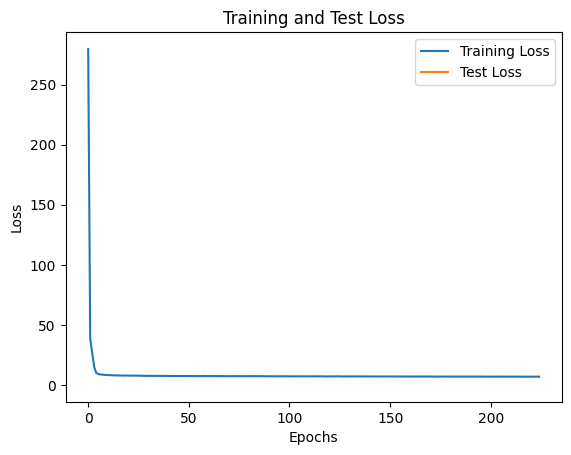

In [18]:
plt.plot([x.cpu().item() for x in loss_overall], label='Training Loss')  # Move tensors to CPU before plotting
plt.plot([avg_test_loss], label='Test Loss') # avg_test_loss is already on cpu and a single value, so just enclose in a list.
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Test Loss')
plt.legend()
plt.show()

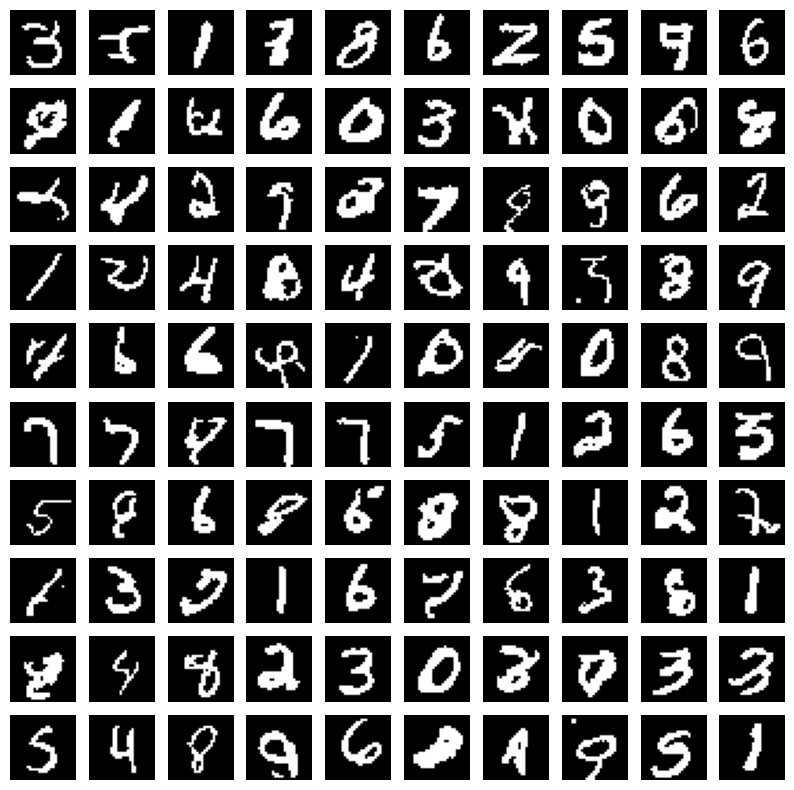

In [15]:
def generate(model, num_samples=100, device=None):
    model.eval()
    generated_images = []
    with torch.no_grad():
        for _ in range(num_samples):
            image = torch.zeros(1, 1, 28, 28).to(device)
            for i in range(28):
                for j in range(28):
                    output = model(image)
                    probs = torch.softmax(output[:, :, i, j], dim=1)
                    pixel_value = torch.multinomial(probs, num_samples=1)
                    image[:, :, i, j] = pixel_value.float()
            generated_images.append(image.squeeze().cpu())
    return generated_images

generated_samples = generate(model, num_samples=100, device=device)

plt.figure(figsize=(10, 10))
for i in range(100):
  plt.subplot(10, 10, i + 1)
  plt.imshow(generated_samples[i], cmap='gray')
  plt.axis('off')
plt.show()